In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy as sp
import scipy.io.wavfile as wf
import librosa
import librosa.display
import IPython.display as ipd
import os
import soundfile as sf
import lightgbm
%matplotlib inline
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
train_df = pd.read_csv('development.csv')
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']
audiopath = train_df['path'].tolist()

audiopath[:5]

['D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-11e9-a9a5-5dbec3b8816a.wav']

In [ ]:
train_df['intention'] = train_df.pop('action') + train_df.pop('object')

,Id,path,speakerId,Self-reported fluency level,First Language spoken,Current language used for work/school,gender,ageRange,intention
0,0,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,change languagenone
1,1,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,activatemusic
2,2,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,deactivatelights
3,3,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
4,4,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
...,...,...,...,...,...,...,...,...,...
9849,9849,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,decreasevolume
9850,9850,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights
9851,9851,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights
9852,9852,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,native,English (United States),English (United States),male,22-40,deactivatelights


c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


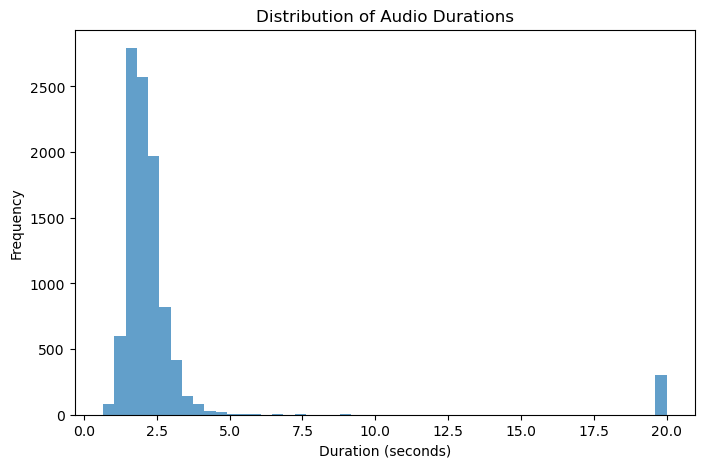

Upper duration bound: 3.48 seconds
Trimmed and saved 9854 files to:
D:\Data Science and Engineering\Datasets\dsl_data\trimmed audio


In [4]:
import os
import librosa
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt

# --- Set your custom output path ---
output_dir = r"D:\Data Science and Engineering\Datasets\dsl_data\trimmed audio"
os.makedirs(output_dir, exist_ok=True)

# --- Step 1: Get durations for each path in train_df['path'] ---
def get_audio_duration(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        return librosa.get_duration(y=y, sr=sr)
    except Exception as e:
        print(f"Failed on {file_path}: {e}")
        return None

train_df["duration"] = train_df["path"].apply(get_audio_duration)

# Remove rows with failed duration extraction
train_df = train_df[train_df["duration"].notnull()]

# --- Step 2: Visualize and compute upper bound using IQR ---
plt.figure(figsize=(8, 5))
plt.hist(train_df["duration"], bins=50, color="tab:blue", alpha=0.7)
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Audio Durations")
plt.show()

Q1 = train_df["duration"].quantile(0.25)
Q3 = train_df["duration"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"Upper duration bound: {upper_bound:.2f} seconds")

# --- Step 3: Trim long audios and save to the custom folder ---
def trim_and_save_audio(file_path, max_duration, output_dir):
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        if duration > max_duration:
            y = y[:int(sr * max_duration)]
        
        # Save to new path
        filename = os.path.basename(file_path)
        new_path = os.path.join(output_dir, filename)
        sf.write(new_path, y, sr)
        return new_path, librosa.get_duration(y=y, sr=sr)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

# Process each file and save trimmed version
new_paths = []
new_durations = []

for path in train_df["path"]:
    new_path, new_duration = trim_and_save_audio(path, upper_bound, output_dir)
    new_paths.append(new_path)
    new_durations.append(new_duration)

train_df["new_path"] = new_paths
train_df["new_duration"] = new_durations

# Remove any failed rows
train_df = train_df[train_df["new_path"].notnull()]

# --- Done ---
print(f"Trimmed and saved {len(train_df)} files to:\n{output_dir}")

In [6]:
audiopath_new = train_df['new_path'].tolist()

audiopath_new[:5]

['D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\0a3129c0-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\0ee42a80-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\1d9f3920-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\269fc210-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:\\Data Science and Engineering\\Datasets\\dsl_data\\trimmed audio\\5bbda3f0-4478-11e9-a9a5-5dbec3b8816a.wav']

In [7]:
DBT2 = []
mfccs2 = []
target_length = 231525  # 10.5 seconds in samples (assuming 22050 Hz sample rate)
top_db = 20  # dB threshold for trimming

for path in tqdm(audiopath_new, desc="Processing Audio"):
    # Load audio (retain original sample rate)
    x, sr = librosa.load(path, sr=None)

    # Get duration (avoid redundant file reading)
    duration_before_trim = len(x) / sr

    # Trim silence
    trimmed_audio, _ = librosa.effects.trim(x, top_db=top_db)

    # Pad or truncate to the target length
    processed_audio = librosa.util.fix_length(trimmed_audio, size=target_length)

    # Extract MFCCs
    mfcc2 = librosa.feature.mfcc(y=processed_audio, sr=sr)

    # Store results
    DBT2.append(duration_before_trim)
    mfccs2.append(mfcc2)

Processing Audio: 100%|██████████| 9854/9854 [04:37<00:00, 35.45it/s]


In [22]:
mfcc = sklearn.preprocessing.scale(mfcc2, axis=1)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:261: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:280: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


In [ ]:
feature= np.array(mfccs2)
feature= feature.reshape(feature.shape[0], -1)
# X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

In [33]:
x = feature
y = train_df['intention']

In [34]:
# X = X[..., np.newaxis]  # Reshape for CNN: (samples, 13, 100, 1)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=4, stratify=y)

In [35]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [37]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(13, 100, 1)),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y)), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_encoded, epochs=30, batch_size=32, validation_split=0.1)


Epoch 1/30


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 9060), dtype=float32). Expected shape (None, 13, 100, 1), but input has incompatible shape (None, 9060)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 9060), dtype=float32)
  • training=True
  • mask=None

In [ ]:
model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)